# Librerías

In [ ]:
import os
import glob
import random
import numpy as np
import pandas as pd
from pathlib import Path
import SimpleITK as sitk
import matplotlib.pyplot as plt
from collections import defaultdict
from matplotlib.patches import Rectangle
from sklearn.model_selection import train_test_split

# Visualizar un Slice

(194, 512, 512)


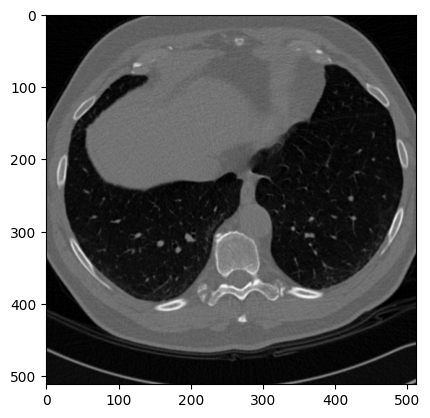

In [3]:
#Este lee tanto el .mhd y el .raw
scan = sitk.ReadImage(
 "data/subset8/1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222365663678666836860.mhd"
)
#Este convierte el CT a NumPy
image = sitk.GetArrayFromImage(scan)
#Este imprime (slices,alto,ancho)
print(image.shape)
#Este selleciona el slice 50 y lo dibuja -> con los dos comandos de abajo veo un slice pero es una sola tomografia
plt.imshow(image[70], cmap='gray')
plt.show()

# Información una tomografía

In [4]:
#Enteder el rango de HU 
print(image.min())
print(image.max())
#Tipo de dato de voxel
print(image.dtype)
#El primer dato del shape #slice,alto,ancho
print(image.shape[0])

-1024
3071
int16
194


# Ver anotaciones

In [5]:
annotations = pd.read_csv("data/annotations.csv")
annotations.head()

,seriesuid,coordX,coordY,coordZ,diameter_mm
0,1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222...,-128.699421,-175.319272,-298.387506,5.651471
1,1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222...,103.783651,-211.925149,-227.121250,4.224708
2,1.3.6.1.4.1.14519.5.2.1.6279.6001.100398138793...,69.639017,-140.944586,876.374496,5.786348
3,1.3.6.1.4.1.14519.5.2.1.6279.6001.100621383016...,-24.013824,192.102405,-391.081276,8.143262
4,1.3.6.1.4.1.14519.5.2.1.6279.6001.100621383016...,2.441547,172.464881,-405.493732,18.545150


# Buscar tomografía según annotations

In [6]:
#solo la columna seriesuid de mi csv [4] es el número de fila
seriesuid = annotations.iloc[4]['seriesuid']
found_path = None
#recorre todos mis subset para encontrar el q es
for subset in range(10):
    #construir la ruta
    folder = f"data/subset{subset}"
    #recorre los archivos
    for file in os.listdir(folder):
        #Para buscar coincidencias y decir este es 
        if file.startswith(seriesuid):
            found_path = os.path.join(folder, file)
            break
    if found_path:
        break
print(found_path)

data/subset2\1.3.6.1.4.1.14519.5.2.1.6279.6001.100621383016233746780170740405.mhd


## Abre tomografía encontrada

(321, 512, 512)


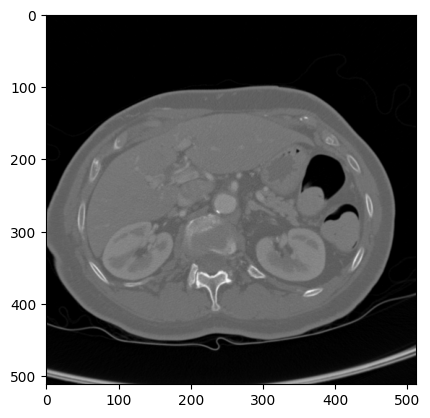

In [7]:
scan = sitk.ReadImage(found_path)
image = sitk.GetArrayFromImage(scan)
print(image.shape)
plt.imshow(image[50], cmap='gray')
plt.show()

## Encuentra Slice donde está el nodulo

-405.4937318
251


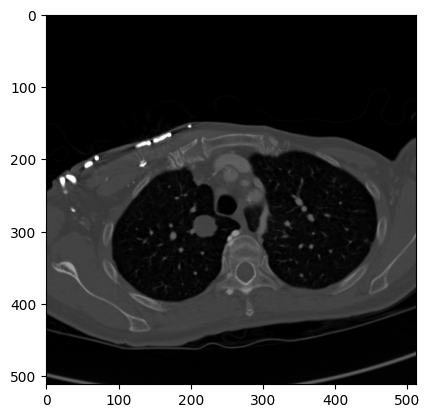

In [8]:
#este pa tomar la fila, imprime la coordenada Z de ese fila 
coordZ = annotations.iloc[4]['coordZ']
print(coordZ)
#Donde empieza mi CT
origin = scan.GetOrigin()
#Cuanto mide el voxel
spacing = scan.GetSpacing()
slice_index = int((coordZ - origin[2]) / spacing[2])
print(slice_index)
plt.imshow(image[slice_index], cmap='gray')
plt.show()

## Encuentra el nodulo

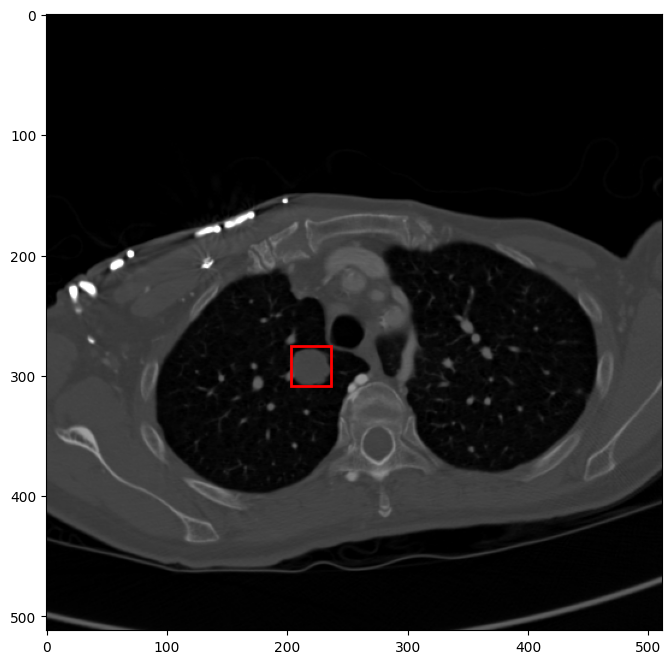

In [9]:
fila = annotations.iloc[4]
coordX = fila['coordX']
coordY = fila['coordY']
diameter_mm = fila['diameter_mm']  

pixelX = int((coordX - origin[0]) / spacing[0])
pixelY = int((coordY - origin[1]) / spacing[1])

ancho_px = diameter_mm / spacing[0]
alto_px  = diameter_mm / spacing[1]

x0 = pixelX - ancho_px / 2
y0 = pixelY - alto_px / 2

plt.figure(figsize=(8,8))
plt.imshow(image[slice_index], cmap='gray')

rect = Rectangle((x0, y0), ancho_px, alto_px,
                 linewidth=2, edgecolor='red', facecolor='none')
plt.gca().add_patch(rect)

plt.show()

## Slice cercanos

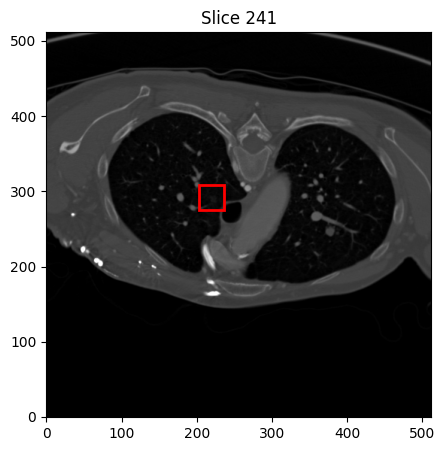

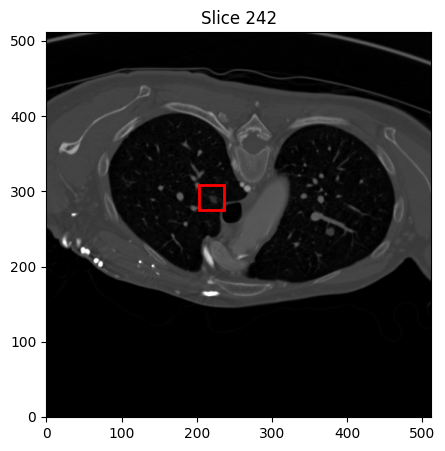

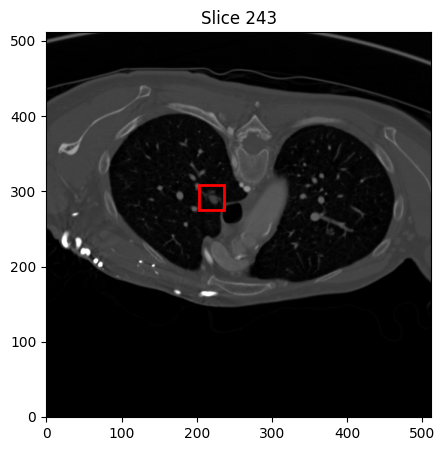

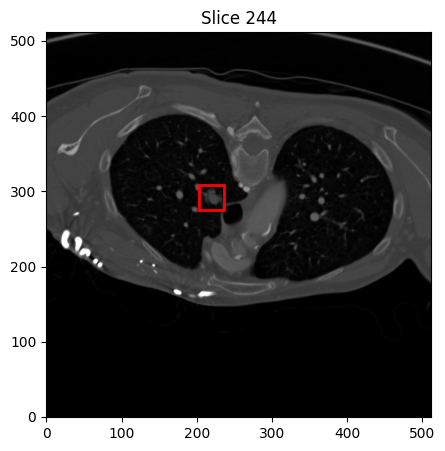

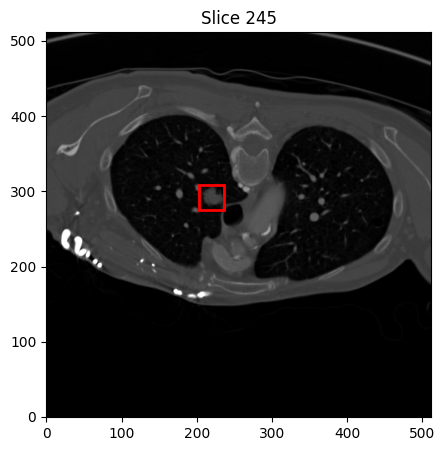

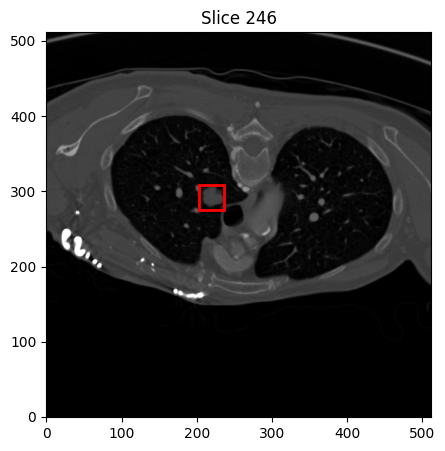

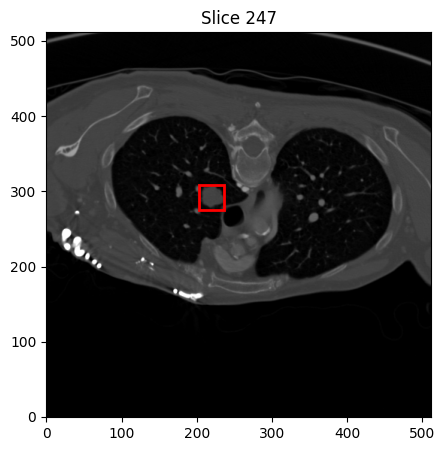

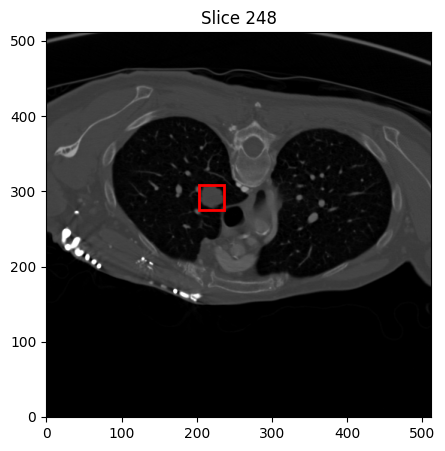

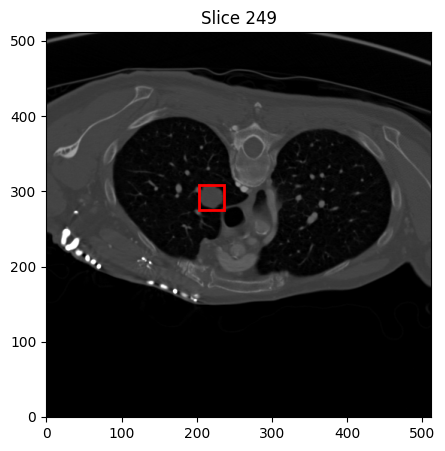

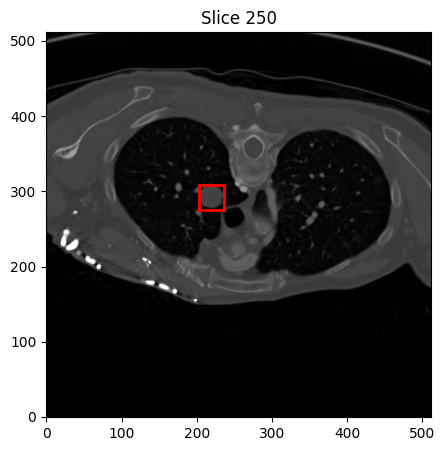

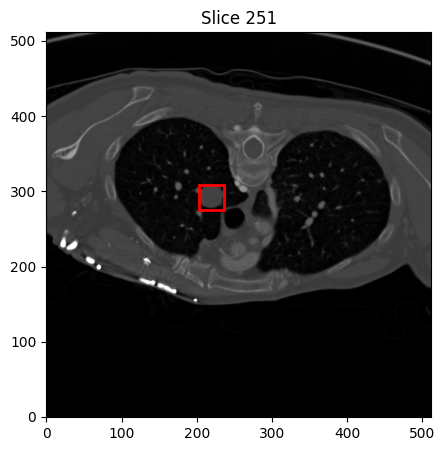

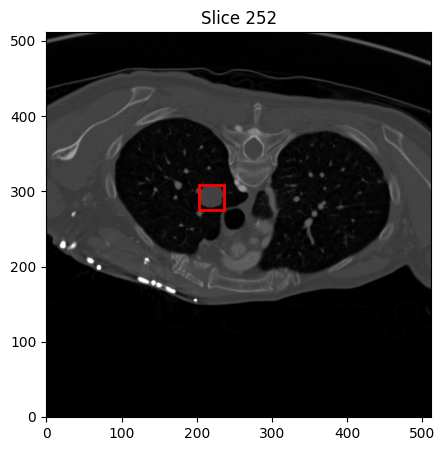

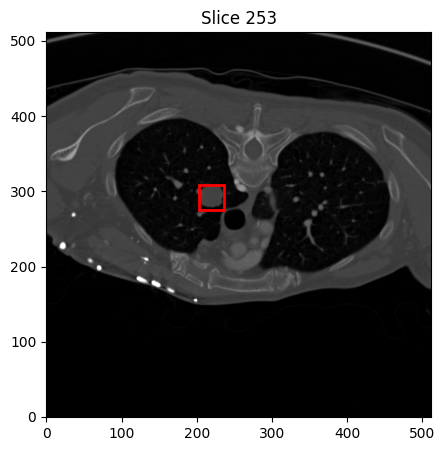

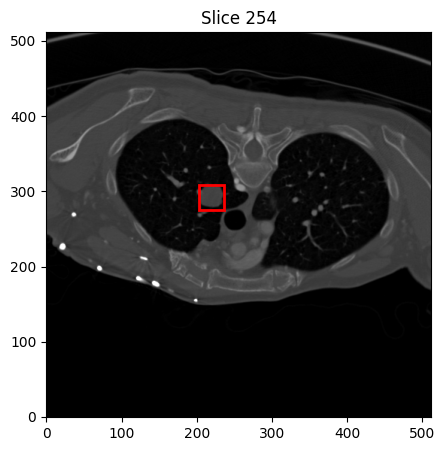

In [11]:
for i in range(slice_index - 10, slice_index + 4):
    plt.figure(figsize=(5,5))
    plt.imshow(image[i], cmap='gray', origin='lower')
    plt.title(f"Slice {i}")
    
    rect = Rectangle((x0, y0), ancho_px, alto_px,
                     linewidth=2, edgecolor='red', facecolor='none')
    plt.gca().add_patch(rect)
    
    plt.show()

# Exploración del dataset

In [13]:
base_path = Path("data")
slices_por_tomografia = {}

for subset_dir in base_path.glob("subset*"):
    if subset_dir.is_dir():
        for mhd_file in subset_dir.glob("*.mhd"):
            seriesuid = mhd_file.stem
            try:
                reader = sitk.ImageFileReader()
                reader.SetFileName(str(mhd_file))
                reader.ReadImageInformation()
                size = reader.GetSize()
                num_slices = size[2]
                slices_por_tomografia[seriesuid] = num_slices
                print(f"{seriesuid}: {num_slices} slices")
            except Exception as e:
                print(f"Error en {mhd_file}: {e}")

df_slices = pd.DataFrame(list(slices_por_tomografia.items()),
                         columns=['seriesuid', 'num_slices'])
df_slices.to_csv("slices_por_tomografia.csv", index=False)
print("\n Datos guardados en 'slices_por_tomografia.csv'")
print(f"Total: {len(df_slices)} tomografías procesadas.")

1.3.6.1.4.1.14519.5.2.1.6279.6001.105756658031515062000744821260: 121 slices
1.3.6.1.4.1.14519.5.2.1.6279.6001.108197895896446896160048741492: 119 slices
1.3.6.1.4.1.14519.5.2.1.6279.6001.109002525524522225658609808059: 161 slices
1.3.6.1.4.1.14519.5.2.1.6279.6001.111172165674661221381920536987: 538 slices
1.3.6.1.4.1.14519.5.2.1.6279.6001.122763913896761494371822656720: 124 slices
1.3.6.1.4.1.14519.5.2.1.6279.6001.124154461048929153767743874565: 195 slices
1.3.6.1.4.1.14519.5.2.1.6279.6001.126121460017257137098781143514: 133 slices
1.3.6.1.4.1.14519.5.2.1.6279.6001.126264578931778258890371755354: 672 slices
1.3.6.1.4.1.14519.5.2.1.6279.6001.128023902651233986592378348912: 133 slices
1.3.6.1.4.1.14519.5.2.1.6279.6001.129055977637338639741695800950: 483 slices
1.3.6.1.4.1.14519.5.2.1.6279.6001.130438550890816550994739120843: 274 slices
1.3.6.1.4.1.14519.5.2.1.6279.6001.134996872583497382954024478441: 197 slices
1.3.6.1.4.1.14519.5.2.1.6279.6001.137763212752154081977261297097: 246 slices

## Número de registros

In [14]:
print(annotations.shape)

(1186, 5)


## Información

In [15]:
annotations.info()

<class 'pandas.DataFrame'>
RangeIndex: 1186 entries, 0 to 1185
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   seriesuid    1186 non-null   str    
 1   coordX       1186 non-null   float64
 2   coordY       1186 non-null   float64
 3   coordZ       1186 non-null   float64
 4   diameter_mm  1186 non-null   float64
dtypes: float64(4), str(1)
memory usage: 46.5 KB


In [18]:
annotations.describe()

,coordX,coordY,coordZ,diameter_mm
count,1186.000000,1186.000000,1186.000000,1186.000000
mean,-5.067547,8.428113,-160.159029,8.306527
std,84.468115,98.316003,279.829437,4.762033
min,-164.351031,-283.834336,-790.074799,3.253443
25%,-80.909225,-51.549643,-221.197808,5.107177
50%,-32.855132,18.787926,-167.615160,6.433600
75%,76.830069,67.245915,-109.735281,9.696301
max,164.763985,271.405521,1790.494057,32.270030


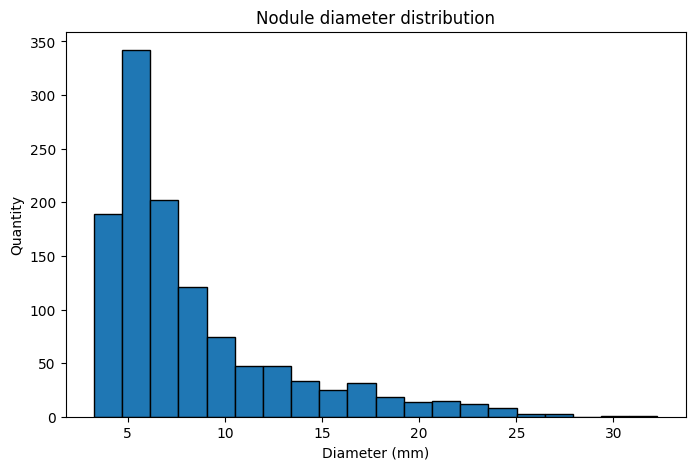

In [21]:
plt.figure(figsize=(8,5))
plt.hist(
    annotations["diameter_mm"],
    bins=20,
    edgecolor="black"
)
plt.xlabel("Diameter (mm)")
plt.ylabel("Quantity")
plt.title("Nodule diameter distribution")
plt.show()

In [20]:
print(df_slices['num_slices'].describe())

count    888.000000
mean     255.884009
std      133.761188
min       95.000000
25%      137.750000
50%      237.500000
75%      305.000000
max      764.000000
Name: num_slices, dtype: float64


Total tomografías: 888
Con nódulo: 601
Sin nódulo: 287


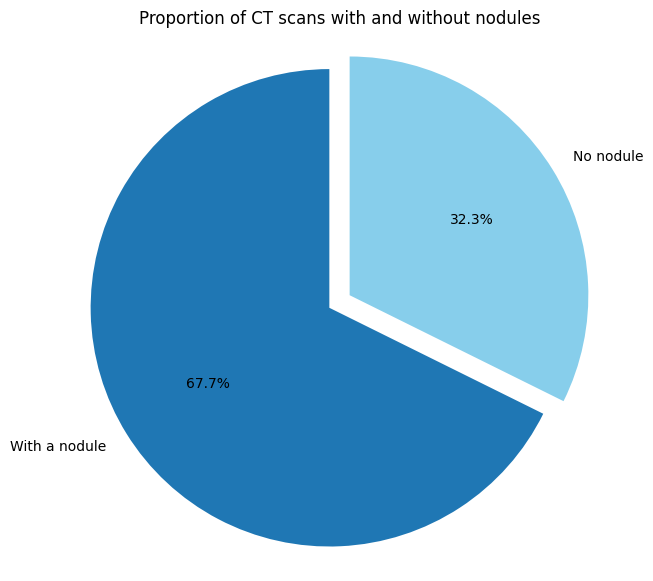

In [25]:
todas_tomografias = set(df_slices['seriesuid'])
tomografias_con_nodulo = set(annotations['seriesuid'])

con_nodulo = len(tomografias_con_nodulo)
sin_nodulo = len(todas_tomografias - tomografias_con_nodulo)
total = len(todas_tomografias)

print(f"Total tomografías: {total}")
print(f"Con nódulo: {con_nodulo}")
print(f"Sin nódulo: {sin_nodulo}")

labels = ['With a nodule', 'No nodule']
sizes = [con_nodulo, sin_nodulo]
colors = ['#1f77b4', '#87CEEB']
explode = (0.05, 0.05)

plt.figure(figsize=(7,7))
plt.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90, explode=explode)
plt.title('Proportion of CT scans with and without nodules')
plt.axis('equal') 
plt.show()

# Revisar CT corruptos

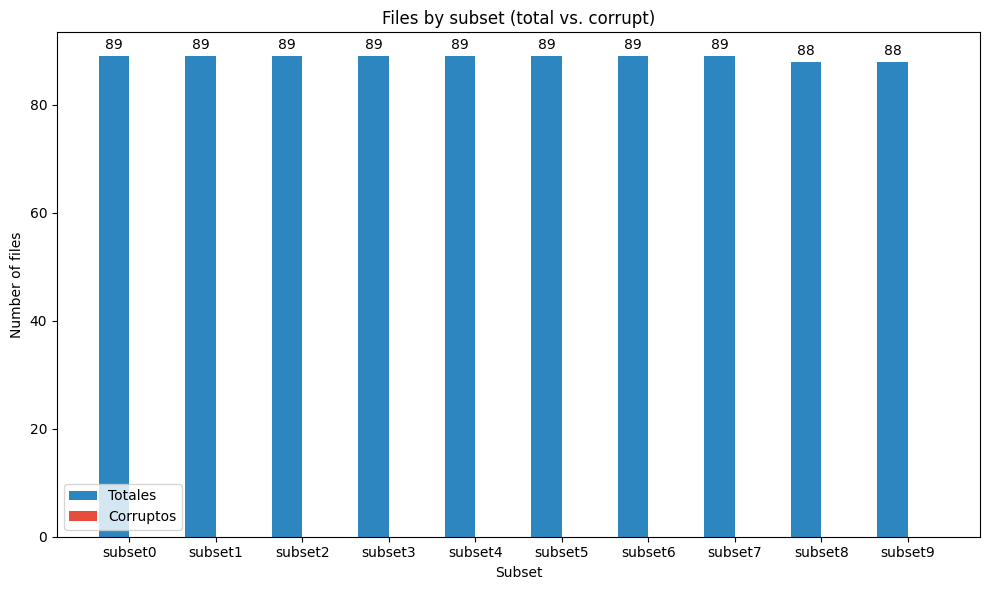

In [30]:
subsets = list(totales_por_subset.keys())
totales = [totales_por_subset[s] for s in subsets]
corruptos = [len(corruptos_por_subset[s]) for s in subsets]

x = range(len(subsets))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x, totales, width, label='Totales', color='#2E86C1')
bars2 = ax.bar([i + width for i in x], corruptos, width, label='Corruptos', color='#E74C3C')

ax.set_xlabel('Subset')
ax.set_ylabel('Number of files')
ax.set_title('Files by subset (total vs. corrupt)')
ax.set_xticks([i + width/2 for i in x])
ax.set_xticklabels(subsets)
ax.legend()

for bar in bars1:
    height = bar.get_height()
    ax.annotate(f'{height}', xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', va='bottom')
for bar in bars2:
    height = bar.get_height()
    if height > 0:
        ax.annotate(f'{height}', xy=(bar.get_x() + bar.get_width()/2, height),
                    xytext=(0, 3), textcoords="offset points", ha='center', va='bottom')

plt.tight_layout()
plt.show()